## 0. Preparation
### 0.1 Load Modules

In [42]:
import gdown
import os
import xarray as xr
import numpy as np
import pandas as pd
import matplotlib.pyplot as plt
from matplotlib.animation import FuncAnimation
from IPython.display import HTML
import cmcrameri.cm as cmc
import hvplot.xarray

### 0.2 Download data

the data was downloaded yousing the following *Google Earth Engine* script: https://code.earthengine.google.com/04afb4de7a1d95d988d2972e3ed87ffd.
--> downloads interpolated image of the 1st of July 1st of each 3-year block

Band positions: *1. Blue, 2. Green , 3. Red, 4. NIR, 5. SWIR1, 6. SWIR2, 7. TIR1*

#### Automatic download from Google Drive:

In [43]:
# Create data directory
data_folder = "../data/raw"
os.makedirs(data_folder, exist_ok=True)

# Dictionary of file IDs per year(alway the first of 3-year block)
datasets = {
    1985:"1gdgTwrMUVVMpNC5YYTU3LkgNEutjRUM5",
    1988:"1lYyrBD97drS3H_pxI0nLmXpU4S9Zw8b1",
    1991:"1JxT2CNw6y1RTHXwFJ0nm-_4unLJxBRUJ",
    1994:"1TOFy-yTz5KNsVAH-dh0YejLSb8pAqFas",
    1997:"1ysdgB8XYwEEYXl578CMQzVK8ZZ2XHTku",
    2000:"1s7Nnl80wGbMh1xyEV7Dx9YqaZPNpOZb_",
    2003:"11ES9OyhetkfvH8DTOi5BCJdoWVLCCQX7",
    2006:"1S-LoLT967qDS8d1bp_wXaRnja0JscuJu",
    2009:"1doUkH38hT1tle41qeQ7AH8aDjGIQ0F90",
    2012:"1o4sFKySMZl1e2W9cGU3EyB4KCO9CvJZh",
    2015:"1XwhUhv3FW4sFx3ubGf9v-dyq9I-Idq_b",
    2018:"1t16HUGh17ldTojX3lrt3MMH_PA2R3kV4",
    2021:"1qh7ZLAOw36l28qs8JJlaKs6FzcjmLigY",
    2024:"1mc0cWZgh6rm0YfZuPlIm8FWJKvMfsDQc"
}

#create array containing all years
year_list = np.arange(1985, 2025, 3)

#loop through them an download missing files
for year in year_list:
    filepath = f"../data/raw/LandsatComposite_Zurich_{year}.tif"
    fileID = datasets[year]
    if not os.path.exists(filepath):
        print(f"Downloading {filepath}...")
        url = f"https://drive.google.com/uc?id={fileID}"
        gdown.download(url, filepath, quiet=False)
    else:
        print(f"{filepath} already exists")


../data/raw/LandsatComposite_Zurich_1985.tif already exists
../data/raw/LandsatComposite_Zurich_1988.tif already exists
../data/raw/LandsatComposite_Zurich_1991.tif already exists
../data/raw/LandsatComposite_Zurich_1994.tif already exists
../data/raw/LandsatComposite_Zurich_1997.tif already exists
../data/raw/LandsatComposite_Zurich_2000.tif already exists
../data/raw/LandsatComposite_Zurich_2003.tif already exists
../data/raw/LandsatComposite_Zurich_2006.tif already exists
../data/raw/LandsatComposite_Zurich_2009.tif already exists
../data/raw/LandsatComposite_Zurich_2012.tif already exists
../data/raw/LandsatComposite_Zurich_2015.tif already exists
../data/raw/LandsatComposite_Zurich_2018.tif already exists
../data/raw/LandsatComposite_Zurich_2021.tif already exists
../data/raw/LandsatComposite_Zurich_2024.tif already exists


### 0.3 Load Data 

In [44]:
#create empty arrays to store data
LST_array = []
Red_array = []
NIR_array = []

#add data from every year (seperat files)
for year in year_list:
        filepath = f"../data/raw/LandsatComposite_Zurich_{year}.tif"
        with xr.open_dataset(filepath, engine = "rasterio") as src: # only open needed bands
            src_t = src.expand_dims(time=[year])# add time as a coordinate
            LST_array.append(src_t.sel(band = 7).band_data)
            Red_array.append(src_t.sel(band = 3).band_data)
            NIR_array.append(src_t.sel(band = 4).band_data)
            

# turn into xr-array
Red = xr.concat(Red_array, dim = "time")
NIR = xr.concat(NIR_array, dim = "time")
LST = xr.concat(LST_array, dim="time")



### 0.4 calculate  °C and NDVI
To make the values of LST more intuitive, they are converted to °C
The NDVI is calculated. A filtered version is made for analysis where we only want to look at what is classified as vegetation (e.g 1.1 and 1.3)

In [45]:
# change LST unit from K into °C 
LST = LST - 273.15 

#calculate raw NDVI
NDVI = (NIR - Red)/(NIR + Red)
#set overly large values to 1 ()
NDVI = NDVI.clip(min=-1, max=1)


# produce thresholded layer
THRESHOLD = 0.3 # standart for mixed vegetation
NDVI_filtered = NDVI.where(NDVI >= THRESHOLD)

### 0.5 RGB picture for reference
This codeblock generates a true color image to give contex to the following analysis

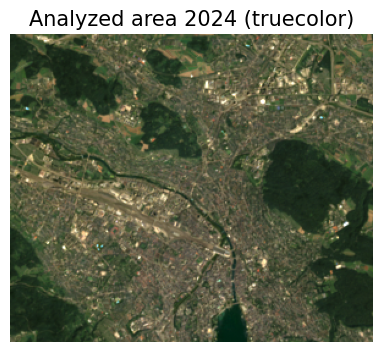

In [46]:
def normalize(array, vmin=0, vmax=0.2):
    """Normalize and clip array to a specific range (default 0 to 0.4)"""
    # Clip the array to the specified vmin and vmax
    clipped = np.clip(array, vmin, vmax)
    # Scale the clipped array to 0-1 for display
    return (clipped - vmin) / (vmax - vmin)

#select a year
reference_year = 2024
if  not reference_year in year_list:#check if selected year is valid
          print(f"{reference_year} is not an available file")

else:
    #extract rgb bands from reference year
    with xr.open_dataset(f"../data/raw/LandsatComposite_Zurich_{reference_year}.tif", engine = "rasterio") as src:
                # load bands and get rid of outlieres for effective visualization 
                Blue_ref = normalize(src.sel(band = 1).band_data)
                Green_ref = normalize(src.sel(band = 2).band_data)
                Red_ref = normalize(src.sel(band=3).band_data)

    #stack the bands
    rgb = np.dstack((Red_ref, Green_ref, Blue_ref))

    fig, ax = plt.subplots(figsize = (8,4))
    ax.imshow(rgb)
    ax.set_title(f"Analyzed area {reference_year} (truecolor)", fontsize = 15)
    ax.set_axis_off()

    fig.savefig(f"../outputs/0_5_reference_picture_RGB")

## 1. How did LST and NDVI change from 1985 to 2024?
### 1.1 Simple Visualization of the Variabels
This code produces interactive hvplot animations of LST and NDVI in the different years

In [47]:
def limits(array, p = 2):
    """returns upper and lower perectile of an array 
    (default: vmin = 2nd percentile, vmax = 98th percentile)"""
    vmin = np.percentile(array, p)
    vmax = np.percentile(array, 100-p)
    return vmin, vmax
    

#plot LST
LST_min_hv, LST_max_hv = limits(LST)

LST_hvplot = LST.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.lajolla_r,
              clim = (LST_min_hv, LST_max_hv),
              clabel = "Land Surface Temperature [°C]", 
              aspect='equal',
              title = "LST in Zurich (1985-2024)",
              fontsize = 15, 
              xaxis = None, yaxis = None)


NDVI_filtered = NDVI.where(NDVI >= THRESHOLD)
#plot NDVI
NDVI_min_hv, NDVI_max_hv = limits(NDVI_filtered) 
#NDVI_max_hv=np.percentile(NDVI, 98)               #only max used -->almost no negative values
NDVI_hvplot = NDVI_filtered.hvplot(x = "x", y = "y", groupby = "time", cmap = "YlGn",
              clim = (THRESHOLD, 1),# 1 = normal upper limit of NDVI
              clabel = "NDVI", 
              aspect='equal',
              title = "NDVI in Zurich (1985-2024)",
              fontsize = 15,
              shared_axes = False, 
              xaxis = None, yaxis = None,
              bgcolor="lightgray")


LST_hvplot + NDVI_hvplot

BokehModel(combine_events=True, render_bundle={'docs_json': {'8fd68121-c18f-49e3-94cc-117d2f766cc0': {'version…

### 1.2 NDVI change in reference to 1985
This code calculates the difference of each layer to the reference year creates an animation through time


In [48]:
#calculate difference 
LST_dif = LST.sel(time = slice(1988,2024)) - LST.sel(time = 1985)

#set boundaries for visualisation centerd around 0
LST_min, LST_max = limits(LST_dif)
LST_boundry = max(abs(LST_min), abs(LST_max))# center around 0

#animate LST
LSTdif = LST_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.vik,
              clim = (-LST_boundry, LST_boundry),
              clabel = "Change in LST in reference to 1985", 
              aspect='equal',
              title = "Change in LST in respect to 1985",
              fontsize = 15,
              shared_axes = False, 
              xaxis = None, yaxis = None)

#calculate difference 
NDVI_dif = NDVI.sel(time = slice(1988,2024)) - NDVI.sel(time = 1985)

#set boundaries for visualisation centerd around 0
NDVI_min, NDVI_max = limits(NDVI_dif)
NDVI_boundry = max(abs(NDVI_min), abs(NDVI_max))# center around 0

#animate NDVI
NDVIdif = NDVI_dif.hvplot(x = "x", y = "y", groupby = "time", cmap = cmc.bam,
              clim = (-NDVI_boundry, NDVI_boundry),
              clabel = "Change in NDVI in reference to 1985", 
              aspect='equal',
              title = "Change in NDVI in respect to 1985",
              fontsize = 15,
              shared_axes = False, 
              xaxis = None, yaxis = None)


#show plots
LSTdif + NDVIdif

BokehModel(combine_events=True, render_bundle={'docs_json': {'9f9931ef-d811-4655-95c2-ef44aefeddb1': {'version…

###  1.3 Modelling change in Collapsed space
In this Segment, the spatial extent of the data is collapsed, resulting in one overall value per 3-annual period. To these values, a linear model is fitted to measure the rate of change.
For LST, the aggreagtinf functio used is the mean. For NDVI, the number of pixels that exceed the THRESHOLD are counted and convertet to km^2

In [49]:
# change in overall LST
LST_mean = LST.mean(dim =["x","y"])
LST_mean_fit = LST_mean.polyfit(dim = "time", deg = 1)
LST_mean_trend_line = xr.polyval(LST_mean.time, LST_mean_fit.polyfit_coefficients)

# change in overall NDVI 
pixelsize = NDVI.rio.resolution()
NDVI_sum = NDVI_filtered.sum(dim =["x","y"])*(pixelsize[0]**2)/ 1000000## to get km^2 instead of pixels

NDVI_sum_fit = NDVI_sum.polyfit(dim = "time", deg = 1)
NDVI_sum_trend_line = xr.polyval(NDVI_sum.time, NDVI_sum_fit.polyfit_coefficients)


The calculated slope is plotted with the data for both datasets

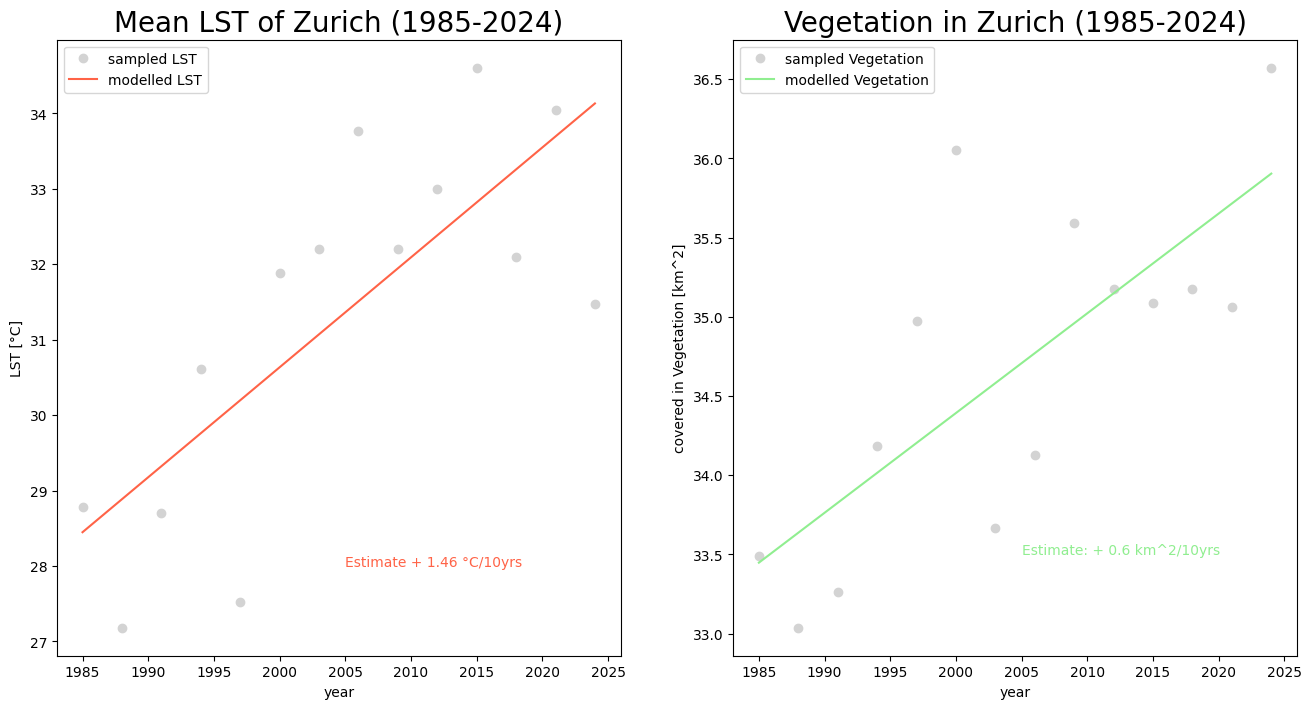

In [50]:
fig, ax = plt.subplots(1,2, figsize = (16,8))

LST_mean.plot(ax = ax[0],marker = "o", ls= "", label = "sampled LST", color = "lightgrey")
LST_mean_trend_line.plot(ax = ax[0], label = "modelled LST", color = "tomato")
ax[0].set_title("Mean LST of Zurich (1985-2024)",fontsize = 20)
ax[0].legend()
ax[0].set_ylabel("LST [°C]")
ax[0].set_xlabel("year")
ax[0].annotate(f"Estimate + {LST_mean_fit.polyfit_coefficients[0]*10:.2f} °C/10yrs", (2005,28), color = "tomato")

NDVI_sum.plot(ax = ax[1], marker = "o", ls = "", label = "sampled Vegetation", color = "lightgrey")
NDVI_sum_trend_line.plot(ax= ax[1], label = "modelled Vegetation", color = "lightgreen")
ax[1].set_title("Vegetation in Zurich (1985-2024)",fontsize = 20)
ax[1].legend()
ax[1].set_ylabel("covered in Vegetation [km^2]")
ax[1].set_xlabel("year")
ax[1].annotate(f"Estimate: + {(NDVI_sum_fit.polyfit_coefficients[0]*10):.1f} km^2/10yrs", (2005,33.5), color = "lightgreen")

fig.savefig(f"../outputs/1_3_Modelling_collapsed_space", bbox_inches = "tight")

### 1.4 Modelling Change pixelwise
Here, similarly to 2.3, the rate of change is measured using a linear regression, but this time a regrssion is fitted for every pixel seperatly.
For easier interpretation, the slope values are changed from annual rates to per decade values.

In [51]:
# change in LST per pixel
LST_fit = LST.polyfit(dim = "time", deg = 1)
LST_slope10 = LST_fit.polyfit_coefficients.sel(degree = 1)*10 

#change in NDVI per pixel
NDVI_fit = NDVI.polyfit(dim = "time", deg = 1)
NDVI_slope10 = NDVI_fit.polyfit_coefficients.sel(degree = 1)*10

The slope of ervery pixel is mapped onto seperate maps for LST and NDVI

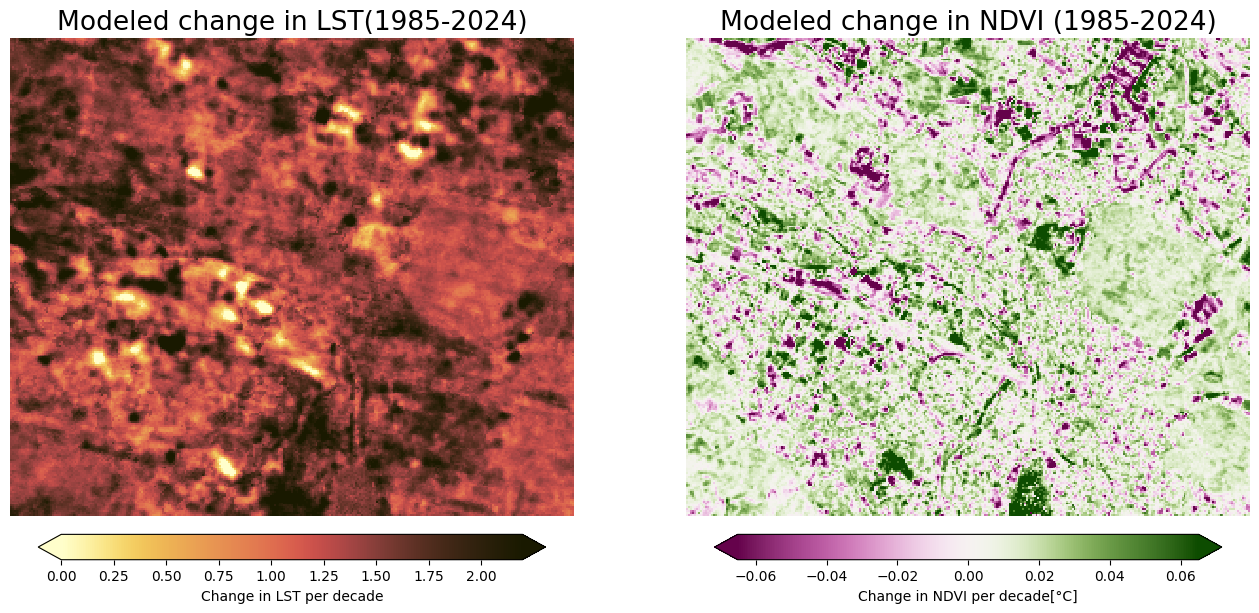

In [52]:
fig, ax = plt.subplots(1,2, figsize = (16,8))

# plot slope of LST
LST_slope_min, LST_slope_max = limits(LST_slope10)
LST_slope_boundry = max(abs(LST_slope_min), abs(LST_slope_max))

LST_slope10.plot(ax=ax[0], 
                 vmin = 0 ,
                 vmax = LST_slope_boundry, 
                 cmap = cmc.lajolla_r,
                 cbar_kwargs = {"label" : "Change in LST per decade", "shrink" : 0.9, "pad": 0.03, "location" : "bottom"})
ax[0].set_axis_off()
ax[0].set_title("Modeled change in LST(1985-2024)", fontsize = 19)
ax[0].set_aspect('equal')

#plot slope of NDVI
NDVI_slope_min, NDVI_slope_max = limits(NDVI_slope10)
NDVI__slope_boundry = max(abs(NDVI_slope_min), abs(NDVI_slope_max))

NDVI_slope10.plot(ax= ax[1], 
                  vmin = - NDVI__slope_boundry, 
                  vmax = NDVI__slope_boundry, 
                  cmap = cmc.bam, 
                  cbar_kwargs = {"label" : "Change in NDVI per decade[°C]", "shrink" : 0.9, "pad": 0.03, "location" : "bottom"})
ax[1].set_axis_off()
ax[1].set_title("Modeled change in NDVI (1985-2024)", fontsize = 19)
ax[1].set_aspect('equal')

fig.savefig(f"../outputs/1_4_Modelling_pixelwise", bbox_inches = "tight")

## 2. How do NDVI und LST correlate and is this corelation effected by climate change?
### 2.1. How do NDVI und LST correlate?
Here, we fit a linear regression with LST as the response and NDVI as the explainer variable. To better see the relation between the 2 variables, we only look at one year, otherwise the effect of climate change masks the patterns.

In [53]:
#extract data
year = 2024 ## select a year
NDVI_y = NDVI.sel(time = year, method = "nearest")
LST_y = LST.sel(time=year, method = "nearest")

# bind NDVI and LST into one np array to use np.polyfit later
combined = np.column_stack((NDVI_y.values.flatten(), LST_y.values.flatten()))
## filter out lake/waterbodies from analysis(large leverage)
comb_filtered = combined[combined[:,0] >= 0]

# calculate correlation
LST_NDVI_fit = np.polyfit(comb_filtered[:,0], comb_filtered[:,1], deg = 1)
intercept = LST_NDVI_fit[1]
slope = LST_NDVI_fit[0]

Plotting of LST agains NDVI. Every Pixel is plotted with a very low alpha, so we can see where most ponts are more easily. The calculated regression line is then plotted on top

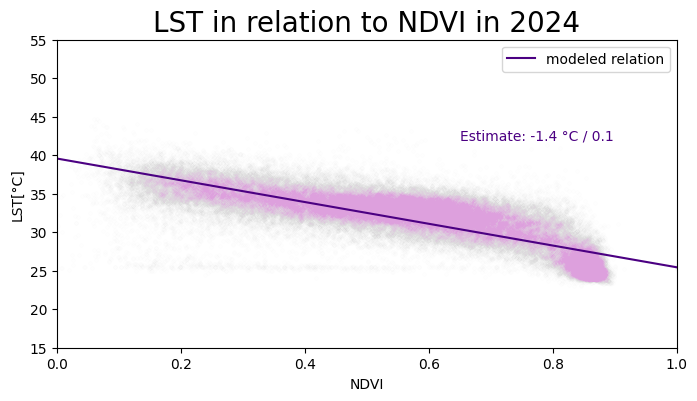

In [54]:
fig, ax = plt.subplots(figsize = (8,4))

ax.scatter(comb_filtered[:,0], comb_filtered[:,1], marker = ".", alpha = 0.005, c ="plum")
ax.axline((0,intercept),slope=slope, color = "indigo", label = "modeled relation")
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)
ax.set_title(f"LST in relation to NDVI in {year}", fontsize = 20)
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")
ax.legend()
ax.annotate(f"Estimate: {slope * 0.1:.1f} °C / 0.1", (0.65,42), color = "indigo")

fig.savefig(f"../outputs/2_1_LST_to_NDVI_{year}", bbox_inches = "tight")


### 2.2 Does the Correlation change with the advance of climate change?

In this section. the regression line is calculated for every year seperatly.

In [55]:
#generate slope and intercept for every year
year_fits = []
for i, year in enumerate(NDVI.time.values):
    NDVI_y = NDVI.sel(time = year)
    LST_y = LST.sel(time = year)
    LST_NDVI_y= np.polyfit(NDVI_y.values.flatten(), LST_y.values.flatten(), deg = 1)
    intercept_y = LST_NDVI_y[1]
    slope_y = LST_NDVI_y[0]

    year_fits.append({"intercept": intercept_y,
                       "slope" : slope_y, 
                       "color" : i, 
                       "label" : f"{year}"})

The slopes are then added one after another to the plot to get a feeling for the change in time

In [60]:
#define function on what changes in animation with each frame
def update(frame):
    """takes the frame and draws the corrsponding line, updates the label to fit the time"""
    #get year specific data
    fit = year_fits[frame]

    #draw line
    line = ax.axline(
        (0, fit["intercept"]),
        slope=fit["slope"],
        color=colors[fit["color"]],
        linewidth=2)
    
    
    #update year annotation
    time.set_text(fit["label"])
    return line, time

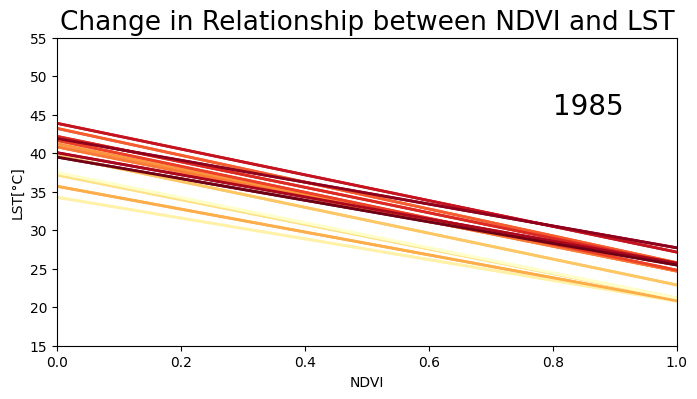

In [73]:
fig, ax = plt.subplots(figsize = (8,4))

# adding year of annotation to ax
time = ax.annotate("", (0.8,45), fontsize = 20)

# defines 1 color for every year to make a gradtient fro yellow to red
colors = ['#ffffcc', '#fff2a8', '#fee187', '#fdc766', '#fdae4b', '#fd943f', '#fb7a36',
            '#f55c2e', '#ec4027', '#dc2a22', '#c5141f', '#ab071d', '#8e001b', '#700016']

#create animation
ani = FuncAnimation(
    fig,
    update,# the function defined in the block above
    frames=len(year_fits),
    interval=800)

#configure ax
ax.set_xlim(xmin = 0, xmax= 1)
ax.set_ylim(15, 55)
ax.set_title("Change in Relationship between NDVI and LST", fontsize = 19)
ax.set_xlabel("NDVI")
ax.set_ylabel("LST[°C]")

###fig.savefig(f"../outputs/2_2_NDVI_LST_all_years") leere fig
display(HTML(ani.to_jshtml()))
ani.save('../outputs/test.apng', writer="pillow")


### 2.3 export data for significance testing
From every year, NDVI, LST and year are exported as a datapoint into a .csv in /data, to perform significance testing in R.

In [58]:
data_folder = "../data/processed"
os.makedirs(data_folder, exist_ok=True)

In [59]:
rows = []# prepare empty list
ndvi_vals = NDVI.values.flatten()#flatten the cubes we can iterate through them
lst_vals = LST.values.flatten()

for year in NDVI.time.values:
    for ndvi, lst in zip(ndvi_vals, lst_vals):
        rows.append({
            "NDVI": ndvi,
            "LST": lst,
            "year": year
            })

NDVI_LST = pd.DataFrame(rows)

NDVI_LST.to_csv("../data/processed/NDVI_LST.csv", index = False)
